# Математическая статистика для анализа больших данных.
## Задание 11
### Introduction to Causal Inference

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

!pip install dowhy
import dowhy.gcm as gcm
from dowhy.gcm import EmpiricalDistribution, ClassifierFCM

import matplotlib.pyplot as plt
import seaborn as sns

---

### Задача 1 (5 баллов).

При проведении испытания лекарства получены следующие данные. В каждом случае указано количество успешных случаев.


| Количество успешных        | Принимали плацебо | Принимали лекарство  |
| :------------- |-------------:| -----:|
| Низкое давление      | 81 из 87 | 234 из 270 |
| Высокое давление     | 192 из 263      |   55 из 80 |


На семинаре вы оценили эффект в случае, когда кровяное давление пациентов измерялось до начала испытания, после чего принималось решение о приеме лекарства. А теперь оцените эффект в случае, когда *кровяное давление пациентов измерялось в конце испытания. При этом известно, что лекарство может оказывать эффект на кровяное давление, которое в свою очередь может оказывать эффект на выздоровление.*


**1.** Выполните следующие действия


- Нарисуйте граф причинно-следственных связей для каждого случая.
- Выпишите плотность марковского распределения на графе.
- Определите численно оценку каждой компоненты плотности. Все распределения дискретны, поэтому надо указать оценки всех необходимых условных вероятностей.

Z измеряется в КОНЦЕ испытания

Теперь ситуация меняется. Предположим следующий причинно-следственный механизм:

- Сначала назначается лечение $X$.
- Лекарство может изменить кровяное давление к моменту окончания испытания, то есть $X \to Z$.
- Измеренное в конце давление $Z$ влияет на результат $Y$, то есть $Z \to Y$.

Слово в условии: «лекарство может оказывать эффект на кровяное давление, которое в свою очередь может оказывать эффект на выздоровление.» Это подсказывает структуру «$X$ влияет на $Z$, $Z$ влияет на $Y$». Теперь $Z$ — это не предвещающий фактор, а промежуточная переменная (медиатор).

**Граф для нового случая:**

$$X \to Z \to Y.$$

Теперь $Z$ не предшествует $X$, а следует за ним. Также из условия напрямую не сказано о прямой связи $X \to Y$. Можно считать, что основной путь влияния $X$ на $Y$ идёт через $Z$. Поэтому возьмём упрощённый граф без прямого ребра $X \to Y$.

**Марковское факторизующее разложение:**

$$p(X, Z, Y) = p(X) \cdot p(Z \mid X) \cdot p(Y \mid Z).$$

Здесь мы воспользовались цепочкой: $X$ порождает $Z$, а $Z$ порождает $Y$.

### Оценки компонент:

#### $p(X)$:
Изначально 350 человек на плацебо $(X=0)$ и 350 на лекарстве $(X=1)$.

$$p(X=0) = \frac{350}{700} = 0.5, \quad p(X=1) = \frac{350}{700} = 0.5.$$

---

#### $p(Z \mid X)$:
Рассчитаем для каждой группы $X$:

1. Если $X=0$ (плацебо): всего 350 человек.  
   Среди них $Z=0$ (низкое давление) у 87 человек, $Z=1$ (высокое давление) у 263 человек.

   $$p(Z=0 \mid X=0) = \frac{87}{350} \approx 0.2486, \quad p(Z=1 \mid X=0) = \frac{263}{350} \approx 0.7514.$$

2. Если $X=1$ (лекарство): всего 350 человек.  
   Среди них $Z=0$ у 270 человек, $Z=1$ у 80 человек.

   $$p(Z=0 \mid X=1) = \frac{270}{350} \approx 0.7714, \quad p(Z=1 \mid X=1) = \frac{80}{350} \approx 0.2286.$$
---

#### $p(Y \mid Z)$:
Теперь считаем результаты, сгруппировав всех людей по $Z$, независимо от $X$, так как по графу $Y$ зависит только от $Z$.

1. Для $Z=0$: всего 357 человек $(87+270)$.  
   Успешных: $81$ (при $X=0$) + $234$ (при $X=1$) = $315$.

   $$p(Y=1 \mid Z=0) = \frac{315}{357} \approx 0.8829, \quad p(Y=0 \mid Z=0) = \frac{42}{357} \approx 0.1178.$$

2. Для $Z=1$: всего 343 человека $(263+80)$.  
   Успешных: $192$ (при $X=0$) + $55$ (при $X=1$) = $247$.

   $$p(Y=1 \mid Z=1) = \frac{247}{343} \approx 0.72, \quad p(Y=0 \mid Z=1) = \frac{96}{343} \approx 0.2796.$$





**2.** Сначала все посчитаем ручками.

* Посчитайте обычную оценку эффекта (ассоциация) между исследуемыми группами (лекарство/плацебо). Сравните с эффектом по группам относительно низкого и высокого давления.


* Посчитайте оценку причинно-следственного эффекта (ATE) с помощью интервенции, поясняя, что означает каждая величина в выражении.


* Посчитайте оценку причинно-следственного эффекта на экспериментальной группе (ATT) с помощью интервенции, поясняя, что означает каждая величина в выражении.


* Посчитайте оценку смещения между группами. *См. утверждение с лекции.*

Сделайте выводы.

**Общее число человек**: 700 (350 принимали плацебо $(X=0)$, 350 принимали лекарство $(X=1)$).

#### Распределение успехов и неудач:

| Количество успешных        | Принимали плацебо | Принимали лекарство  |
| :------------- |-------------:| -----:|
| Низкое давление      | 81 из 87 | 234 из 270 |
| Высокое давление     | 192 из 263      |   55 из 80 |

####  Перепишем:

|                 | **Принимали плацебо $(X=0)$**      | **Принимали лекарство $(X=1)$**      |
|-----------------|-----------------------------------|-------------------------------------|
| Низкое давление $(Z=0)$ | $81/87$ успех $(Y=1)$, $6/87$ неуспех    | $234/270$ успех, $36/270$ неуспех   |
| Высокое давление $(Z=1)$ | $192/263$ успех, $71/263$ неуспех         | $55/80$ успех, $25/80$ неуспех      |

---

### Подсчёты без стратификации и по группам $Z$

#### Без стратификации:

- **Всего успехов при $X=0$**: $81 + 192 = 273$ из $350$  
  $$E[Y \mid X=0] = \frac{273}{350} = 0.78.$$

- **Всего успехов при $X=1$**: $234 + 55 = 289$ из $350$  
  $$E[Y \mid X=1] = \frac{289}{350} = 0.826.$$

---

#### По $Z$:

- **При $Z=0$**:  
  - $X=0$: $\frac{81}{87} \approx 0.931$  
  - $X=1$: $\frac{234}{270} \approx 0.867$  
  Разность: $\approx -0.064$ (лекарство хуже).

- **При $Z=1$**:  
  - $X=0$: $\frac{192}{263} \approx 0.73$  
  - $X=1$: $\frac{55}{80} = 0.6875$  
  Разность: $\approx -0.0425$ (лекарство тоже хуже).

---

### Парадокс Симпсона

Наивное сравнение (без стратификации):  
$$E[Y \mid X=1] - E[Y \mid X=0] = 0.826 - 0.78 = 0.046.$$

*Сравнение внутри групп $Z$:  
Для каждой группы $Z$ эффект отрицательный, но без учёта $Z$ общее сравнение даёт $+0.046$ в пользу лекарства.

---

### Причинно-следственный анализ

#### ATE (Средний причинный эффект):

1. Распределения $p(Z \mid X)$:
   - Для $X=0$:
   $$p(Z=0 \mid X=0) = \frac{87}{350} \approx 0.2486, \quad p(Z=1 \mid X=0) = \frac{263}{350} \approx 0.7514.$$
   - Для $X=1$:
  $$p(Z=0 \mid X=1) = \frac{270}{350} \approx 0.7714, \quad p(Z=1 \mid X=1) = \frac{80}{350} \approx 0.2286.$$

2. Распределения $p(Y \mid Z)$:
   - Для $Z=0$:  
     $$p(Y=1 \mid Z=0) = \frac{315}{357} \approx 0.8829.$$
   - Для $Z=1$:  
     $$p(Y=1 \mid Z=1) = \frac{247}{343} \approx 0.72.$$

3. Подсчёт $ATE$:  
   $$E[Y(X=1)] = p(Y=1 \mid Z=0) \cdot p(Z=0 \mid X=1) + p(Y=1 \mid Z=1) \cdot p(Z=1 \mid X=1).$$
   Подставим:  
   $$E[Y(X=1)] \approx 0.8829 \cdot 0.7714 + 0.72 \cdot 0.2286 \approx 0.681 + 0.165 = 0.846.$$

   Аналогично для $X=0$:  
   $$E[Y(X=0)] = p(Y=1 \mid Z=0) \cdot p(Z=0 \mid X=0) + p(Y=1 \mid Z=1) \cdot p(Z=1 \mid X=0).$$
   Подставим:  
   $$E[Y(X=0)] = 0.8829 \cdot 0.2486 + 0.72 \cdot 0.7514 = 0.2195 + 0.541 = 0.7605.$$

   Тогда:  
   $$ATE = E[Y(X=1)] - E[Y(X=0)] = 0.846 - 0.7605 = 0.0855.$$

**Вывод**: Если бы всем назначили лекарство, вероятность успеха была бы $\approx 84.6\%$, а если бы всем назначили плацебо — $\approx 76.05\%$. Чистый эффект лекарства $\approx 8.55\%$.

---

#### ATT (Эффект на обработанных):

1. Определение:
   $$ATT = E[Y(X=1) \mid X=1] - E[Y(X=0) \mid X=1].$$

2. Известно:
   $$E[Y(X=1) \mid X=1] = E[Y \mid X=1] = 0.826.$$

3. Подсчёт $E[Y(X=0) \mid X=1]$:  
   $$E[Y(X=0) \mid X=1] \approx p(Y=1 \mid Z=0) \cdot p(Z=0 \mid X=0) + p(Y=1 \mid Z=1) \cdot p(Z=1 \mid X=0).$$
   $$E[Y(X=0) \mid X=1] \approx 0.8829 \cdot 0.2486 + 0.72 \cdot 0.7514 \approx 0.2195 + 0.541 = 0.7605.$$

4. Тогда:
   $$ATT = 0.826 - 0.7605 = 0.0655.$$

**Вывод**: Для тех, кто реально получил лекарство, если бы им дали плацебо, успех составил бы $\approx 76.05\%$ против фактических $\approx 82.6\%$. Эффект $\approx 6.55\%$.

---

#### **Смещение (bias):**

$$bias = [E(Y \mid X=1) - E(Y \mid X=0)] - [ATE].$$

Подставим:  
$$bias = 0.046 - 0.0855 = -0.0395.$$

**Вывод**: Наивная ассоциация недооценивает истинный причинно-следственный эффект на $3.95\%$.

---

**Вывод**:
При наивном сравнении результатов среди всех пациентов без учета кровяного давления мы видим, что вероятность успеха у группы, принимавшей лекарство, на первый взгляд выше примерно на 4,6%. Однако, если рассмотреть показатели отдельно в группах с низким и высоким давлением, ситуация меняется на противоположную: лекарство кажется менее эффективным внутри каждой подгруппы, что демонстрирует парадокс Симпсона.

Чтобы разрешить это противоречие, необходимо использовать причинно-следственный подход. Оценка среднего причинного эффекта (ATE), предполагающего интервенцию в назначение лечения, показывает, что если бы мы всем пациентам дали лекарство, уровень успеха был бы выше примерно на 8,55% по сравнению с ситуацией, в которой всем дали бы плацебо. Это противоречит наивному сравнению и указывает, что лекарство действительно эффективно, но искажение возникает из-за различий в распределении кровяного давления.

Дополнительно, оценка эффекта среди тех, кто фактически получил лекарство (ATT), дает увеличение около 6,55% — то есть для уже обработанных пациентов лекарство в среднем еще более выгодно, чем кажется при простом сравнении. Таким образом, наивная ассоциация недооценила истинный эффект приблизительно на 3,95%.

В целом, причинно-следственный анализ позволяет учесть скрытые факторы и упорядоченность событий (лечение, затем давление, затем результат), демонстрируя, что лекарство оказывает позитивный причинный эффект на успех лечения, тогда как простой статистический анализ без учета причинно-следственной структуры может ввести в заблуждение.


**3.** Поэкспериментируем с библиотекой DoWhy. Зададим датасет с данными, которые соответствуют нашей задаче

In [ ]:
data = pd.DataFrame()
data['treatment'] = [0]*(87+263) + [1]*(270+80)
data['blood_pressure'] = [0]*87 + [1]*263 + [0]*270 + [1]*80
data['result'] = [1]*81 + [0]*(87-81) + [1]*192 + [0]*(263-192) \
                + [1]*234 + [0]*(270-234) + [1]*55 + [0]*(80-55)
data.index.name = 'patient'

data

,treatment,blood_pressure,result
patient,,,
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
695,1,1,0
696,1,1,0
697,1,1,0


Задайте граф причинно-следственных связей и постройте по нему модель `StructuralCausalModel` с автоматическим определением механизма причинно-следственных связей. Обучите полученную модель

In [ ]:

data = pd.DataFrame()
data['treatment'] = [0]*(87+263) + [1]*(270+80)
data['blood_pressure'] = [0]*87 + [1]*263 + [0]*270 + [1]*80
data['result'] = [1]*81 + [0]*(87-81) + [1]*192 + [0]*(263-192) \
                + [1]*234 + [0]*(270-234) + [1]*55 + [0]*(80-55)
data.index.name = 'patient'

# Задаем причинно-следственный граф
# treatment -> blood_pressure -> result
causal_graph = nx.DiGraph([
    ('treatment', 'blood_pressure'),
    ('blood_pressure', 'result')
])

causal_model = gcm.StructuralCausalModel(causal_graph)

gcm.auto.assign_causal_mechanisms(causal_model, data)

# Обучаем модель
gcm.fit(causal_model, data)

# Проверим, какие механизмы выбраны и их параметры
for node in causal_model.graph.nodes:
    print(f"Node: {node}, Mechanism: {causal_model.causal_mechanism(node)}")

Fitting causal mechanism of node result: 100%|██████████| 3/3 [00:00<00:00, 54.47it/s]

Node: treatment, Mechanism: Empirical Distribution
Node: blood_pressure, Mechanism: Discrete AdditiveNoiseModel using HistGradientBoostingRegressor
Node: result, Mechanism: Discrete AdditiveNoiseModel using Pipeline


Выясните, какие зависимости подобрались и напечатайте параметры этих моделей

In [ ]:
# Получим механизм для blood_pressure
bp_mechanism = causal_model.causal_mechanism('blood_pressure')
print("blood_pressure mechanism:", bp_mechanism)
print("blood_pressure mechanism type:", type(bp_mechanism))

# Если это AdditiveNoiseModel, то внутри есть атрибут prediction_model
if hasattr(bp_mechanism, 'prediction_model'):
    print("blood_pressure prediction model:", bp_mechanism.prediction_model)
    # bp_mechanism.prediction_model.sklearn_model - это базовый sklearn-регрессор
    print("blood_pressure prediction model parameters:", bp_mechanism.prediction_model.sklearn_model.get_params())

# Аналогично для result
res_mechanism = causal_model.causal_mechanism('result')
print("result mechanism:", res_mechanism)
if hasattr(res_mechanism, 'prediction_model'):
    print("result prediction model:", res_mechanism.prediction_model)
    print("result prediction model parameters:", res_mechanism.prediction_model.sklearn_model.get_params())

blood_pressure mechanism: Discrete AdditiveNoiseModel using HistGradientBoostingRegressor
blood_pressure mechanism type: <class 'dowhy.gcm.causal_mechanisms.DiscreteAdditiveNoiseModel'>
blood_pressure prediction model: HistGradientBoostingRegressor()
blood_pressure prediction model parameters: {'categorical_features': 'warn', 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_bins': 255, 'max_depth': None, 'max_features': 1.0, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'monotonic_cst': None, 'n_iter_no_change': 10, 'quantile': None, 'random_state': None, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
result mechanism: Discrete AdditiveNoiseModel using Pipeline
result prediction model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('linearregression', LinearRegression())])
result prediction mo

Как видим, были использованы модели с аддитивным шумом, в то время как наши данные дискретны.

Поменяем тип данных на строковые

In [ ]:
data_str = data.astype(str)

Задайте модели наследования вручную. Если у вершины нет предков, то используйте эмпирическое распределение, иначе &mdash; классификатор `gcm.ClassifierFCM()`. Обучите полученную causal модель

In [ ]:
# (X -> Z -> Y)
causal_graph = nx.DiGraph([
    ('treatment', 'blood_pressure'),
    ('blood_pressure', 'result')
])


causal_model_str = gcm.StructuralCausalModel(causal_graph)


# treatment - без родителей
causal_model_str.set_causal_mechanism('treatment', EmpiricalDistribution())
# blood_pressure - с одним родителем (treatment)
causal_model_str.set_causal_mechanism('blood_pressure', ClassifierFCM())
# result - с одним родителем (blood_pressure)
causal_model_str.set_causal_mechanism('result', ClassifierFCM())

gcm.fit(causal_model_str, data_str)

Fitting causal mechanism of node result: 100%|██████████| 3/3 [00:00<00:00,  7.44it/s]


Наконец, посчитайте оценку ATE с помощью интервенции в построенной модели. Не забудьте, что в качестве значения интервенции нужно указать строку, а полученные семплы перевести обратно в числа перед усреднением.

In [ ]:

# ATE = E[Y(X=1)] - E[Y(X=0)]

# Интервенция в treatment: X=1
samples_treated = gcm.interventional_samples(
    causal_model_str,
    {'treatment': lambda t: '1'},
    num_samples_to_draw=100000
)

# Интервенция в treatment: X=0
samples_untreated = gcm.interventional_samples(
    causal_model_str,
    {'treatment': lambda t: '0'},
    num_samples_to_draw=100000
)


samples_treated['result'] = samples_treated['result'].astype(int)
samples_untreated['result'] = samples_untreated['result'].astype(int)


E_Y1 = samples_treated['result'].mean()
E_Y0 = samples_untreated['result'].mean()

ATE_est = E_Y1 - E_Y0
print("ATE estimation from DoWhy model:", ATE_est)

ATE estimation from DoWhy model: 0.08592999999999995


Сравните результаты с теми, которые посчитали ручками

*Ранее при ручных вычислениях для сценария, в котором кровяное давление измеряется после лечения и считается медиатором (цепочка X → Z → Y), мы получили оценку ATE равной 0.0855. Теперь, используя библиотеку DoWhy и задав механизмы вручную для дискретных данных, мы получили оценку ATE около 0.08593. Эти два результата практически совпадают, различаясь всего на доли процента, что может объясняться случайным сэмплированием при интервенции или погрешностями округления. Такое близкое совпадение подтверждает корректность как наших аналитических рассуждений, так и выбранного подхода к моделированию причинно-следственных связей в DoWhy.*

---

### Задача 2 (10 баллов).

In [ ]:
data = pd.read_excel('covid_data.xlsx')
data

,Unnamed: 0,Country,Age group,Confirmed cases,Confirmed fatalities
0,0,Italy,0-9,43,0
1,1,Italy,10-19,85,0
2,2,Italy,20-29,296,0
3,3,Italy,30-39,470,0
4,4,Italy,40-49,891,1
...,...,...,...,...,...
103,103,South Korea,40-49,1481,3
104,104,South Korea,50-59,1987,15
105,105,South Korea,60-69,1375,39
106,106,South Korea,70-79,719,78


**1.** Рассмотрим данные по заболеваемости и смертности от COVID-19 в марте 2020 года когда пандемия только начиналась. В данных представлена информация по нескольким странам по разным возрастным категориям.

Считайте данные и посчитайте Case Fatality Rate (CFR) &mdash; процент смертности при условии подтвержденного коронавируса

In [ ]:
data = pd.read_excel('covid_data.xlsx')
data['CFR'] = (data['Confirmed fatalities'] / data['Confirmed cases']) * 100
data['CFR'] = data['CFR'].fillna(0)

Будем рассматривать Китай и Италию как довольно разные страны, в которых коронавирус в начале 2020 развивался наиболее стремительно.

Постройте гистограмму для сравнения CFR двух стран по возрастным категориям. Используйте для этого один вызов `seaborn.barplot` с некоторыми параметрами.

<ipython-input-24-46866813c1b5>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Age group', y='CFR', hue='Country', data=subset,


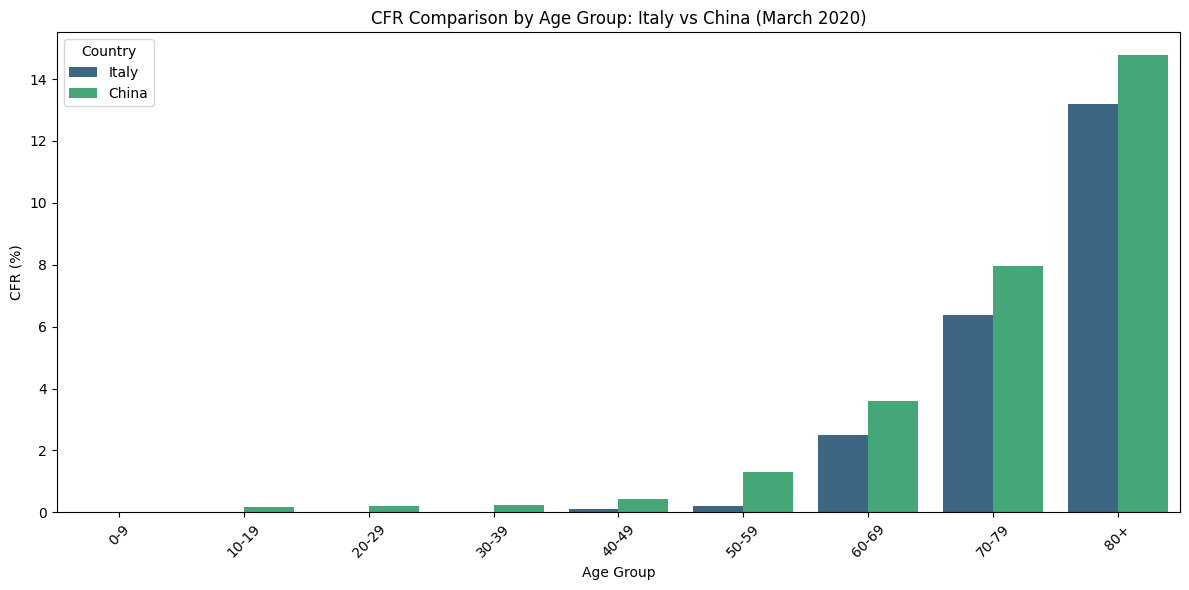

In [ ]:
subset = data[data['Country'].isin(['Italy', 'China'])]

plt.figure(figsize=(12,6))
sns.barplot(x='Age group', y='CFR', hue='Country', data=subset,
            ci=None, palette='viridis')
plt.title('CFR Comparison by Age Group: Italy vs China (March 2020)')
plt.ylabel('CFR (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Теперь посчитайте общую CFR на основе суммарного количества случаев по всем категориями и сравните их для этих двух стран.

In [ ]:
country_totals = data.groupby('Country').agg({
    'Confirmed cases': 'sum',
    'Confirmed fatalities': 'sum'
}).reset_index()

country_totals['Overall_CFR'] = (country_totals['Confirmed fatalities'] / country_totals['Confirmed cases']) * 100
country_totals

,Country,Confirmed cases,Confirmed fatalities,Overall_CFR
0,Argentina,14675,507,3.454855
1,China,44672,1023,2.290025
2,Colombia,25366,822,3.240558
3,Diam. Princ.,619,7,1.130856
4,Italy,8026,357,4.448044
5,Netherlands,45947,5903,12.847411
6,Portugal,31596,1369,4.332827
7,South Africa,27280,577,2.115103
8,South Korea,11190,266,2.377122
9,Spain,258760,20585,7.955248


In [ ]:
italy_cfr = country_totals.loc[country_totals['Country']=='Italy', 'Overall_CFR'].values[0]
china_cfr = country_totals.loc[country_totals['Country']=='China', 'Overall_CFR'].values[0]

print(f'Итоговый CFR в Италии: {italy_cfr:.2f}%')
print(f'Итоговый CFR в Китае: {china_cfr:.2f}%')

Итоговый CFR в Италии: 4.45%
Итоговый CFR в Китае: 2.29%


Что можно наблюдать?

По итоговым данным мы видим, что обобщенная летальность (CFR) сильно различается между странами. Например, в Италии она около 4,45%, в Китае около 2,29%. Это может быть связано с множеством причин: **политическим строем**, разницей в демографической ситуации, в частности возрастной структурой населения, отличиями в методах лечения, доступности медицинской помощи, длительностью периода с момента распространения вируса, своевременностью введения карантинных мер и многими другими факторами. Наблюдаемое различие указывает, что сами по себе «страна» и «CFR» связаны не напрямую, а через комплекс причинных механизмов.

**2.** Итак, мы исследуем три признака: страна, возрастная категория, CFR. Определите на них граф причинно-следственных связей на основе логических соображений и визуализируйте его.

Мы рассматриваем три признака:

- Страна
- Возрастная категория
- CFR

При этом понимаем, что:

Страна определяет демографическую ситуацию (например, долю пожилого населения) и методы лечения.
Демография влияет на распределение возрастных групп зараженных и, следовательно, на летальность, так как возрастные категории сильно коррелируют с тяжестью заболевания и летальностью. Чем старше средний возраст заболевших, тем выше CFR.
Методы лечения, зависящие от страны, могут напрямую влиять на CFR, например, при наличии более современных протоколов, доступных препаратов или лучшей организации здравоохранения.
Для удобства мы разделим фактор «страна» на две компоненты:

- Demography (D) — демографическая ситуация, определяемая страной.
- Treatment methods (T) — методы лечения, свойственные стране.

Таким образом, наш граф причинно-следственных связей может выглядеть так:

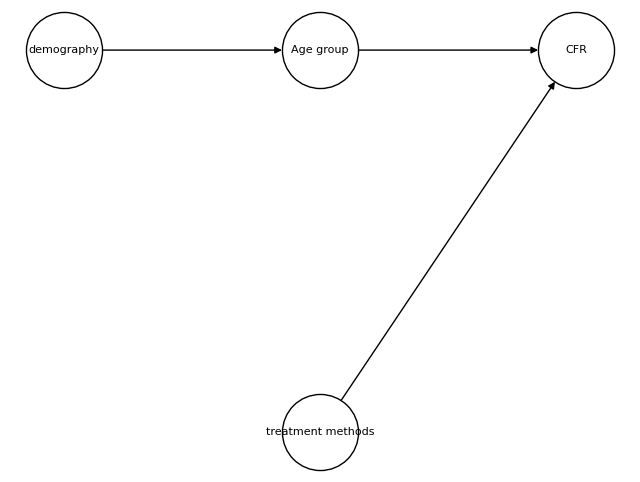

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

causal_graph = nx.DiGraph([
    ('demography', 'Age group'),
    ('treatment methods', 'CFR'),
    ('Age group', 'CFR')
])

pos = {
    'demography': (0, 1),
    'Age group': (1, 1),
    'treatment methods': (1, 0),
    'CFR': (2, 1)
}

plt.figure(figsize=(8, 6))
nx.draw_networkx(causal_graph, pos=pos, with_labels=True, node_size=3000, node_color='white', edgecolors='black', font_size=8)
plt.axis('off')
plt.show()


Для каждой вершины опишите характер причинно-следственной связи. Например, если это линейная регрессия, то надо выписать ее формулу.

Фактор D влияет на Age group (например, более стареющее население => более высокая доля пожилых возрастных категорий среди заболевших). Age group влияет на CFR, так как пожилые группы более уязвимы. Treatment methods (T) — это другая характеристика страны, которая напрямую влияет на CFR (улучшенные методы снижают летальность), но на возрастные группы напрямую не влияет.

Таким образом, факторизация распределения:

$$
p(D, T, \text{Age group}, \text{CFR}) = p(D) p(T \mid D) p(\text{Age group} \mid D) p(\text{CFR} \mid T, \text{Age group})
$$

При этом мы можем задать функциональные формы. Предположим, что:

- **Age group** — категориальная переменная, зависящая от демографии. Например, пусть доля групп меняется в зависимости от $D$. Можно представить это как мультиномиальную регрессию или просто эмпирическое распределение.
- **CFR** зависит линейно от Age group и $T$. Это упрощение, на практике можно использовать более гибкие модели. Допустим, если мы кодируем Age group численно (например, средний возраст категории), то:
  $$
  \text{CFR} = \alpha_0 + \alpha_1 \cdot \text{Age group} + \alpha_2 \cdot T + \epsilon
  $$
  где $T$ тоже можно кодировать категорией (например, one-hot или числовой признак для «методов лечения»). В реальности это дискретная/процентная величина, так что может потребоваться логистическая регрессия или другая модель.


**3.** Сделаем две копии признака "страна":
* `demography` ($D$) &mdash; демографическая ситуация, определяемая страной;
* `treatment methods` ($T$) &mdash; методы лечения, свойственные стране.

Мы делаем такое разделение потому как, например, одна страна может взять методы лечения другой страны, но демографическую ситуацию поменять при этом не получится.

Получается следующий причинно-следственный граф. Визуализируйте его

In [ ]:
causal_graph = nx.DiGraph([
    ('demography', 'Age group'),
    ('treatment methods', 'CFR'),
    ('Age group', 'CFR')
])

Определите по графу causal модель и обучите ее

С помощью интервенции оцените, было бы эффективнее применять в Китае с его демографической ситуацией итальянские методы лечения. Для этого нужно оценить величину
$$NDE = \mathsf{E}(CFR\ |\ D:=China, T:=Italy) - \mathsf{E}(CFR\ |\ D:=China, T:=China),$$
где NDE &mdash; Natural Direct Effect. Используйте достаточно большое количество семплирований.

Теперь, наоборот, оцените, было бы эффективнее применять в Италии с его демографической ситуацией китайские методы лечения.

Наконец, оценим, что было бы если в Китае с его методами лечения демографическая ситуация была бы такой же, как в Италии (Natural Indirect Effect). Какую величину при этом надо посчитать? Посчитайте ее.

Сделайте выводы.

**4.** Наконец, сравните между собой некоторые другие страны. Каким странам вы рекомендовали бы поменять методы лечения на начальном этапе?